# Imports

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import joblib

In [52]:
df = pd.read_csv('../data/df_stats.csv', sep=';', dtype={'Code_INSEE': str})
df_train = df[df['Année'] == 2022].copy()
display(df_train.head(5))
print(f"Dataset chargé : {df_train.shape[0]} lignes, {df_train.shape[1]} colonnes")

print(f"\nDistribution de la cible (vote politique) :")
print(df_train['Résultat'].value_counts())
print(f"\nProportions :")
print(df_train['Résultat'].value_counts(normalize=True).round(4) * 100)

print('\nColonnes :')
print(df_train.columns)

# df_null = df[df.isna().any(axis=1)]
# df = df.dropna()
# print(f"Valeurs manquantes supprimées, df final : {df.shape[0]} lignes, {df.shape[1]} colonnes")

,Année,Code_INSEE,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs,% Blancs/Ins,...,55-64 ans,65-79 ans,80 ans et +,Mariés,Pacsés,Concubinage,Veufs,Divorcés,Célibataires,Population_active
0,2022,01001,L'Abergement-Clémenciat,645,108,16.74,537,83.26,16,2.48,...,131.000000,128.000000,44.000000,357.000000,55.000000,115.000000,41.000000,22.000000,107.000000,697.000000
1,2022,01002,L'Abergement-de-Varey,213,38,17.84,175,82.16,3,1.41,...,26.000000,32.000000,18.000000,103.000000,24.000000,21.000000,7.000000,16.000000,45.000000,216.000000
2,2022,01004,Ambérieu-en-Bugey,8765,2078,23.71,6687,76.29,88,1.00,...,1818.260858,2040.179086,769.098809,5158.413539,734.930321,1253.876355,853.759327,1078.958883,3481.713288,12594.508695
3,2022,01005,Ambérieux-en-Dombes,1282,234,18.25,1048,81.75,14,1.09,...,268.831175,239.134291,86.467498,758.673406,121.875706,220.625154,71.867895,70.087419,311.225980,1554.355560
4,2022,01006,Ambléon,103,23,22.33,80,77.67,3,2.91,...,24.000000,26.000000,6.000000,51.000000,9.000000,11.000000,3.000000,10.000000,20.000000,104.000000


Dataset chargé : 34715 lignes, 54 colonnes

Distribution de la cible (vote politique) :
Résultat
droite    26138
centre     5079
gauche     3498
Name: count, dtype: int64

Proportions :
Résultat
droite    75.29
centre    14.63
gauche    10.08
Name: proportion, dtype: float64

Colonnes :
Index(['Année', 'Code_INSEE', 'Libellé de la commune', 'Inscrits',
       'Abstentions', '% Abs/Ins', 'Votants', '% Vot/Ins', 'Blancs',
       '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins', '% Nuls/Vot',
       'Exprimés', '% Exp/Ins', '% Exp/Vot', '% gauche/Exp', '% centre/Exp',
       '% droite/Exp', 'Résultat', 'Femmes', 'Hommes', 'Agriculteurs',
       'Artisans', 'Cadres', 'Intermédiaires', 'Employés', 'Ouvriers',
       'Retraités', 'Etudiants', 'Inactifs', 'Personne seule', 'Homme seul',
       'Femme seule', 'Colocation', 'Famille', 'Famille monoparentale',
       'Couple sans enfant', 'Couple avec enfants', 'Population avec enfants',
       '15-24 ans', '25-39 ans', '40-54 ans', '55-64 a

# Feature engineering

In [38]:
df_train = df_train.drop(columns=['Année','Libellé de la commune', 'Inscrits', 'Abstentions', '% Abs/Ins', 'Votants', '% Vot/Ins', 'Blancs', '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins', '% Nuls/Vot', 'Exprimés', '% Exp/Ins', '% Exp/Vot', '% gauche/Exp', '% centre/Exp', '% droite/Exp'])


def convert_columns_to_percentages(df, list_columns, divider_column):
    for col in list_columns:
        df[col] = df[col] / df[divider_column] * 100
    return df


# Transformation des genres, catégories socio-professionnelles, tranches d'âge et statuts maritaux en pourcentages de la population active
columns_to_convert = [
    'Hommes', 
    'Femmes', 
    'Agriculteurs', 
    'Artisans', 
    'Cadres', 
    'Intermédiaires', 
    'Employés', 
    'Ouvriers',
    'Retraités',
    'Etudiants',
    'Inactifs',
    '15-24 ans',
    '25-39 ans',
    '40-54 ans',
    '55-64 ans',
    '65-79 ans',
    '80 ans et +',
    'Mariés',
    'Pacsés',
    'Concubinage',
    'Veufs',
    'Divorcés',
    'Célibataires',
]

df_train = convert_columns_to_percentages(df_train, columns_to_convert, 'Population_active')



# Transformation des compositions de ménages en pourcentage de la population avec enfants

columns_to_convert_household = [
    'Personne seule',
    'Homme seul',
    'Femme seule',
    'Colocation',
    'Famille',
    'Famille monoparentale',
    'Couple sans enfant',
    'Couple avec enfants',
]
df_train = convert_columns_to_percentages(df_train, columns_to_convert_household, 'Population avec enfants')

display(df_train)


,Code_INSEE,Résultat,Femmes,Hommes,Agriculteurs,Artisans,Cadres,Intermédiaires,Employés,Ouvriers,...,55-64 ans,65-79 ans,80 ans et +,Mariés,Pacsés,Concubinage,Veufs,Divorcés,Célibataires,Population_active
0,01001,droite,47.184259,52.113958,0.704243,5.633941,10.563640,14.789096,15.493339,17.606067,...,18.794835,18.364419,6.312769,51.219512,7.890961,16.499283,5.882353,3.156385,15.351506,697.000000
1,01002,gauche,41.363637,50.555556,11.489899,2.297980,9.191919,13.787879,9.191919,9.191919,...,12.037037,14.814815,8.333333,47.685185,11.111111,9.722222,3.240741,7.407407,20.833333,216.000000
2,01004,droite,52.881826,47.118174,0.127297,3.114317,7.806622,15.437689,17.760558,15.886919,...,14.436934,16.198957,6.106620,40.957640,5.835323,9.955739,6.778822,8.566899,27.644693,12594.508695
3,01005,droite,51.346262,47.882309,0.362612,6.556032,8.691036,15.289281,21.150485,13.928360,...,17.295346,15.384787,5.562916,48.809515,7.840915,14.193995,4.623646,4.509098,20.022831,1554.355560
4,01006,droite,39.860139,54.807692,0.000000,0.000000,0.000000,9.965035,14.947553,44.842658,...,23.076923,25.000000,5.769231,49.038462,8.653846,10.576923,2.884615,9.615385,19.230769,104.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34710,95676,droite,54.649893,44.135551,0.000000,5.257478,9.135020,24.653834,20.575269,6.438841,...,16.530655,16.979097,4.528522,47.392614,4.639004,15.669851,5.102841,6.176331,21.019359,384.624042
34711,95678,droite,45.606723,51.307563,0.000000,7.838655,16.389916,20.665546,10.689076,5.700840,...,17.428571,13.714286,7.142857,45.714286,10.142857,12.857143,5.000000,4.571429,21.714286,700.000000
34712,95680,gauche,51.602206,48.397794,0.000000,2.962626,4.086016,11.996908,20.954176,17.632084,...,13.628300,10.714654,3.277626,44.969973,1.178277,7.481139,4.148062,5.286505,36.832896,21596.176049
34713,95682,droite,50.000000,50.000000,0.000000,3.125000,15.625000,21.875000,25.000000,9.375000,...,9.027778,7.638889,6.250000,45.138889,6.944444,15.972222,4.166666,3.472222,22.222223,150.857143


In [39]:
# On vérifie que les pourcentages sont corrects

df_test = df_train.copy()
df_test = df_test.drop(columns=['Code_INSEE', 'Résultat', 'Population_active', 'Population avec enfants'])

mask_anomalies = (df_test < 0) | (df_test > 100)
df_anomalies = df_test[mask_anomalies.any(axis=1)]

display(df_anomalies)

,Femmes,Hommes,Agriculteurs,Artisans,Cadres,Intermédiaires,Employés,Ouvriers,Retraités,Etudiants,...,40-54 ans,55-64 ans,65-79 ans,80 ans et +,Mariés,Pacsés,Concubinage,Veufs,Divorcés,Célibataires


In [40]:
# On vérifie les doublons et valeurs manquantes
duplicates_count = df_train.duplicated().sum()
print('Nombre de doublons :', duplicates_count)

null_values_count = df_train.isnull().sum()
print(f'\nNombre de valeurs manquantes : {null_values_count}')

Nombre de doublons : 0

Nombre de valeurs manquantes : Code_INSEE                 0
Résultat                   0
Femmes                     4
Hommes                     4
Agriculteurs               4
Artisans                   4
Cadres                     4
Intermédiaires             4
Employés                   4
Ouvriers                   4
Retraités                  4
Etudiants                  4
Inactifs                   4
Personne seule             4
Homme seul                 4
Femme seule                4
Colocation                 4
Famille                    4
Famille monoparentale      4
Couple sans enfant         4
Couple avec enfants        4
Population avec enfants    4
15-24 ans                  0
25-39 ans                  0
40-54 ans                  0
55-64 ans                  0
65-79 ans                  0
80 ans et +                0
Mariés                     0
Pacsés                     0
Concubinage                0
Veufs                      0
Divorcés         

In [41]:
# On exporte le df en csv
df_train.to_csv('df_model.csv', index=False, sep=';', encoding='utf-8')

# Modélisation

## Split test-train

In [43]:
X = df_train.drop(columns=['Code_INSEE', 'Résultat'])
y = df_train['Résultat']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("✓ Données préparées")
print(f"  Train: {X_train.shape}")
print(f"  Test: {X_test.shape}")

✓ Données préparées
  Train: (24300, 33)
  Test: (10415, 33)


## Fonctions

In [44]:
groups = ['centre', 'droite', 'gauche']


def train_model_and_detect_overfitting(model, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)


    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    gap = abs(train_score - test_score)


    print(f"  Train : {train_score:.2%}")
    print(f"  Test  : {test_score:.2%}")
    print(f"  Gap   : {gap:.2%}\n")


    if gap > 0.10:
        print("⚠️ OVERFITTING détecté !")
    elif train_score < 0.75:
        print("⚠️ UNDERFITTING détecté !")
    else:
        print("✅ Bon équilibre\n")
    
    return y_pred_test, y_pred_train


def display_confusion_matrix(y, y_pred):
    matrix = confusion_matrix(y, y_pred, labels=groups)

    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[f'Prédit {g}' for g in groups],
                yticklabels=[f'Réel {g}' for g in groups])
    plt.title('Matrice de confusion', fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()


def display_metrics(y, y_pred):
    print("\n\nRapport de classification :")
    print(classification_report(y, y_pred, target_names=groups))

## Régression logistique

### Pipeline basique

  Train : 76.34%
  Test  : 76.10%
  Gap   : 0.24%

✅ Bon équilibre


---RÉSULTATS DE LA RÉGRESSION LOGISTIQUE SUR LE TEST



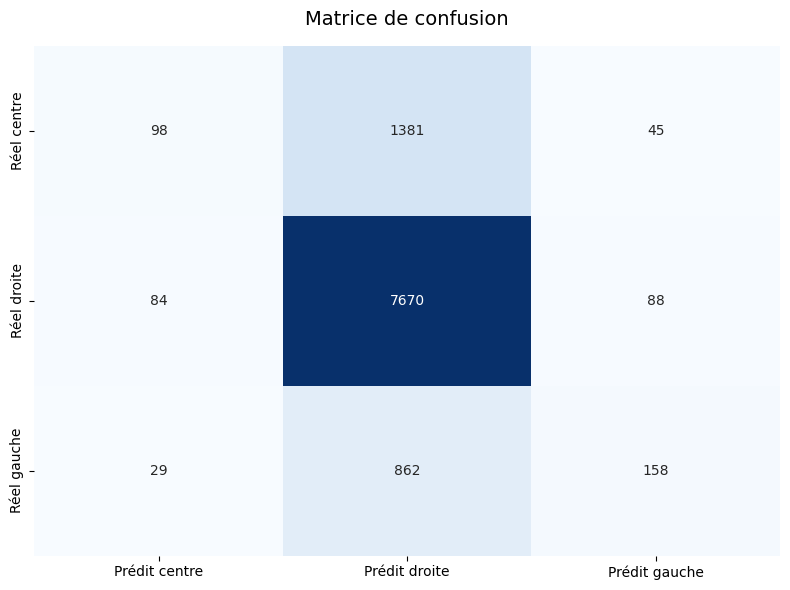



Rapport de classification :
              precision    recall  f1-score   support

      centre       0.46      0.06      0.11      1524
      droite       0.77      0.98      0.86      7842
      gauche       0.54      0.15      0.24      1049

    accuracy                           0.76     10415
   macro avg       0.59      0.40      0.40     10415
weighted avg       0.71      0.76      0.69     10415


---RÉSULTATS DE LA RÉGRESSION LOGISTIQUE SUR LE TRAIN



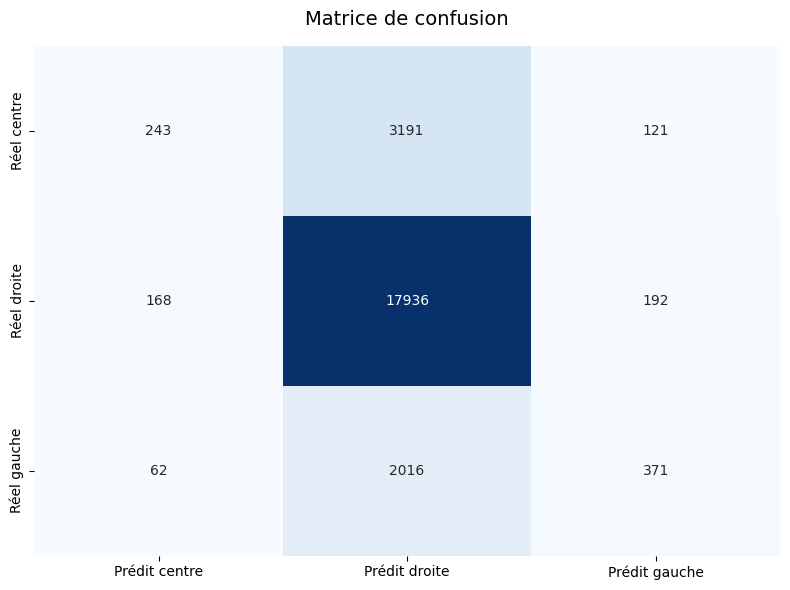



Rapport de classification :
              precision    recall  f1-score   support

      centre       0.51      0.07      0.12      3555
      droite       0.78      0.98      0.87     18296
      gauche       0.54      0.15      0.24      2449

    accuracy                           0.76     24300
   macro avg       0.61      0.40      0.41     24300
weighted avg       0.71      0.76      0.69     24300



In [49]:
logistic = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

logistic.fit(X_train, y_train)
lr_y_pred_test, lr_y_pred_train = train_model_and_detect_overfitting(logistic, y_train, y_test)

# Matrice de confusion et métriques - test
print('\n---RÉSULTATS DE LA RÉGRESSION LOGISTIQUE SUR LE TEST\n')
display_confusion_matrix(y_test, lr_y_pred_test)
display_metrics(y_test, lr_y_pred_test)


# Matrice de confusion et métriques - train
print('\n---RÉSULTATS DE LA RÉGRESSION LOGISTIQUE SUR LE TRAIN\n')
display_confusion_matrix(y_train, lr_y_pred_train)
display_metrics(y_train, lr_y_pred_train)



Recall = Pourcentage de Vrais Positifs (prédictions correctes) d'une classe parmi l'ensemble des positifs de cette classe.  
Sur le graphique : sur chaque ligne (valeurs réelles), pourcentage du 'prédit correct' par rapport au total de la ligne.  
Autrement dit, sur l'ensemble des communes votant à droite, 98 % sont prédites correctement.


__6 % de recall pour le centre et 15 % de recall pour la gauche : très faible en raison du déséquilibre des données__

### SMOTE

In [ ]:
logistic_smote = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy='all')),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


# Entraînement
logistic_smote.fit(X_train, y_train)

lr_y_pred_test_smote, lr_y_pred_train_smote = train_model_and_detect_overfitting(logistic_smote, y_train, y_test)


# Matrice de confusion et métriques - test
print('\n---RÉSULTATS DE LA RÉGRESSION LOGISTIQUE AVEC SMOTE SUR LE TEST\n')
display_metrics(y_test, lr_y_pred_test_smote)


# Matrice de confusion et métriques - train
print('\n---RÉSULTATS DE LA RÉGRESSION LOGISTIQUE AVEC SMOTE SUR LE TRAIN\n')
display_metrics(y_train, lr_y_pred_train_smote)


### Ajustement du poids des classes

In [ ]:
# Modèle avec poids de classes ajustés
logistic_weighted = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])


# Entraînement
logistic_weighted.fit(X_train, y_train)

lr_y_pred_test_weighted, lr_y_pred_train_weighted = train_model_and_detect_overfitting(logistic_weighted, y_train, y_test)


# Matrice de confusion et métriques - test
print('\n---RÉSULTATS DE LA RÉGRESSION LOGISTIQUE AVEC WEIGHTED SUR LE TEST\n')
display_metrics(y_test, lr_y_pred_test_weighted)


# Matrice de confusion et métriques - train
print('\n---RÉSULTATS DE LA RÉGRESSION LOGISTIQUE AVEC WEIGHTED SUR LE TRAIN\n')
display_metrics(y_train, lr_y_pred_train_weighted)

## Random Forest

### Pipeline basique

In [ ]:
forest = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, min_samples_leaf=5, max_features='sqrt', min_samples_split=15))
])

forest.fit(X_train, y_train)
rf_y_pred_test, rf_y_pred_train = train_model_and_detect_overfitting(forest, y_train, y_test)


# Matrice de confusion et métriques - test
print('\n---RÉSULTATS DE LA RANDOM FOREST SUR LE TEST\n')
display_confusion_matrix(y_test, rf_y_pred_test)
display_metrics(y_test, rf_y_pred_test)


# Matrice de confusion et métriques - train
print('\n---RÉSULTATS DE LA RANDOM FOREST SUR LE TRAIN\n')
display_confusion_matrix(y_train, rf_y_pred_train)
display_metrics(y_train, rf_y_pred_train)


### SMOTE

In [ ]:
forest_smote = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy='all')),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, min_samples_leaf=5, max_features='sqrt', min_samples_split=15))
])


# Entraînement
forest_smote.fit(X_train, y_train)

rf_y_pred_test_smote, rf_y_pred_train_smote = train_model_and_detect_overfitting(forest_smote, y_train, y_test)


# Métriques - test
print('\n---RÉSULTATS DE LA RANDOM FOREST AVEC SMOTE SUR LE TEST\n')
display_metrics(y_test, rf_y_pred_test_smote)


# Métriques - train
print('\n---RÉSULTATS DE LA RANDOM FOREST AVEC SMOTE SUR LE TRAIN\n')
display_metrics(y_train, rf_y_pred_train_smote)

### Ajustement du poids des classes

In [ ]:
# Modèle avec poids de classes ajustés
forest_weighted = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=200, random_state=42, max_depth=10, class_weight='balanced', min_samples_leaf=5, max_features='sqrt', min_samples_split=15
    ))
])


# Entraînement et détection d'overfitting
rf_y_pred_test_weighted, rf_y_pred_train_weighted = train_model_and_detect_overfitting(forest_weighted, y_train, y_test)


# Matrice de confusion et métriques - test
print('\n---RÉSULTATS DE LA RANDOM FOREST AVEC WEIGHTED SUR LE TEST\n')
display_metrics(y_test, rf_y_pred_test_weighted)


# Matrice de confusion et métriques - train
print('\n---RÉSULTATS DE LA RANDOM FOREST AVEC WEIGHTED SUR LE TRAIN\n')
display_metrics(y_train, rf_y_pred_train_weighted)

## XGBoost

In [46]:

le = LabelEncoder()

y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.fit_transform(y_test)



### SMOTE

In [ ]:
xgb_smote = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy='all')),
    ('classifier', xgb.XGBClassifier(
        n_estimators=200,       # Nombre d'arbres
        max_depth=5,           # Profondeur des arbres
        learning_rate=0.1,      # Taux d'apprentissage (η)
        subsample=0.8,          # Échantillonnage des données
        colsample_bytree=0.8,   # Échantillonnage des features
        reg_alpha=0.1,          # Régularisation L1
        reg_lambda=1.0,         # Régularisation L2
        random_state=42,
        n_jobs=-1,
        objective='multi:softprob',
        eval_metric='mlogloss'   # Métrique d'évaluation
    ))
])

xgb_y_pred_test_smote, xgb_y_pred_train_smote = train_model_and_detect_overfitting(xgb_smote, y_train_xgb, y_test_xgb)


# Métriques - test
print('\n---RÉSULTATS DE XGBOOST AVEC SMOTE SUR LE TEST\n')
display_metrics(y_test_xgb, xgb_y_pred_test_smote)


# Métriques - train
print('\n---RÉSULTATS DE XGBOOST AVEC SMOTE SUR LE TRAIN\n')
display_metrics(y_train_xgb, xgb_y_pred_train_smote)

### SMOTEENN

In [48]:
xgb_smoteen = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTEENN(random_state=42, smote=SMOTE(sampling_strategy={0: 2000, 1: 10000, 2: 8000}, random_state=42))),
    ('classifier', xgb.XGBClassifier(
        n_estimators=200,       # Nombre d'arbres
        max_depth=5,           # Profondeur des arbres
        learning_rate=0.1,      # Taux d'apprentissage (η)
        subsample=0.8,          # Échantillonnage des données
        colsample_bytree=0.8,   # Échantillonnage des features
        reg_alpha=0.1,          # Régularisation L1
        reg_lambda=1.0,         # Régularisation L2
        random_state=42,
        n_jobs=-1,
        objective='multi:softprob',
        eval_metric='mlogloss'   # Métrique d'évaluation
    ))
])

xgb_y_pred_test_smoteenn, xgb_y_pred_train_smoteenn = train_model_and_detect_overfitting(xgb_smoteen, y_train_xgb, y_test_xgb)


# Métriques - test
print('\n---RÉSULTATS DE XGBOOST AVEC SMOTEENN SUR LE TEST\n')
display_metrics(y_test_xgb, xgb_y_pred_test_smoteenn)


# Métriques - train
print('\n---RÉSULTATS DE XGBOOST AVEC SMOTEENN SUR LE TRAIN\n')
display_metrics(y_train_xgb, xgb_y_pred_train_smoteenn)


ValueError: With over-sampling methods, the number of samples in a class should be greater or equal to the original number of samples. Originally, there is 3555 samples and 2000 samples are asked.

### Class weight

In [ ]:
xgb_weighted = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBClassifier(
        n_estimators=200,       # Nombre d'arbres
        max_depth=5,           # Profondeur des arbres
        learning_rate=0.1,      # Taux d'apprentissage (η)
        subsample=0.8,          # Échantillonnage des données
        colsample_bytree=0.8,   # Échantillonnage des features
        reg_alpha=0.1,          # Régularisation L1
        reg_lambda=1.0,         # Régularisation L2
        random_state=42,
        n_jobs=-1,
        objective='multi:softprob',
        eval_metric='mlogloss'   # Métrique d'évaluation
    ))
])


weights = compute_sample_weight(class_weight='balanced', y=y_train_xgb)


xgb_weighted.fit(X_train, y_train_xgb, classifier__sample_weight=weights)


train_score = xgb_weighted.score(X_train, y_train_xgb)
test_score = xgb_weighted.score(X_test, y_test_xgb)
gap = abs(train_score - test_score)


print(f"  Train : {train_score:.2%}")
print(f"  Test  : {test_score:.2%}")
print(f"  Gap   : {gap:.2%}\n")


if gap > 0.10:
    print("⚠️ OVERFITTING détecté !")
elif train_score < 0.75:
    print("⚠️ UNDERFITTING détecté !")
else:
    print("✅ Bon équilibre\n")


xgb_y_pred_test_weighted = xgb_weighted.predict(X_test)
xgb_y_pred_train_weighted = xgb_weighted.predict(X_train)

# Métriques - test
print('\n---RÉSULTATS DE XGBOOST WEIGHTED SUR LE TEST\n')
display_metrics(y_test_xgb, xgb_y_pred_test_weighted)


# Métriques - train
print('\n---RÉSULTATS DE XGBOOST WEIGHTED SUR LE TRAIN\n')
display_metrics(y_train_xgb, xgb_y_pred_train_weighted)



# Scripts finaux

1. Créer la table d'entraînement dans la base de données à partir du fichier df_model.csv dans ce dossier

## /training/
1. Appeler la table avec les données d'entraînement pour récupérer toutes les données dans un dataframe df_train
2. On applique le script ci-dessous (il faudra l'adapter aux données récupérées + au chemin d'enregistrement du modèle joblib) :

In [53]:
import pandas as pd
import xgboost as xgb
import joblib
from datetime import date

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# split test-train
X = df_train.drop(columns=['Code_INSEE', 'Résultat'])
y = df_train['Résultat']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# Label encoding pour la variable cible car le modèle ne prend pas de valeurs textuelles
le = LabelEncoder()

y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.fit_transform(y_test)


# Pipeline XGBoost + SMOTE
xgb_smote = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy='all')),
    ('classifier', xgb.XGBClassifier(
        n_estimators=200,       # Nombre d'arbres
        max_depth=5,           # Profondeur des arbres
        learning_rate=0.1,      # Taux d'apprentissage (η)
        subsample=0.8,          # Échantillonnage des données
        colsample_bytree=0.8,   # Échantillonnage des features
        reg_alpha=0.1,          # Régularisation L1
        reg_lambda=1.0,         # Régularisation L2
        random_state=42,
        n_jobs=-1,
        objective='multi:softprob',
        eval_metric='mlogloss'   # Métrique d'évaluation
    ))
])


# Entraînement
xgb_smote.fit(X_train, y_train_xgb)


# Enregistrement du modèle en joblib
joblib.dump(xgb_smote, f'models/predilection_model_{date.today()}')

ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: 'Masléon'

## /prediction/

Appliquer le script suivant :


__!!! Attention !!!__ 

Il faudra :
* remplacer l'import du csv par l'appel à la table statistiques en utilisant le code_INSEE de la commune
* gérer les potentielles erreurs si les statistiques sont incomplètes
* remplacer le chemin du fichier lors de l'import joblib

In [54]:
import pandas as pd
import joblib

df_stats = pd.read_csv('../data/src/insee.csv', sep=';', dtype={'Code_INSEE': str})
df_stats = df_stats.sort_values(by=['Code_INSEE', 'Année'])

# On récupère les données de la commune
df_city = df_stats[(df_stats['Code_INSEE'] == '59001') & ((df_stats['Année'] == 2022) | (df_stats['Année'] == 2011))]

# On crée des projections pour 2027
def calculate_2027_value(column):
    value_2011, value_2022 = column.values
    coeff = (float(value_2022) - float(value_2011)) / 11
    projection_2027 = max(float(value_2022) + (coeff * 5), 0)
    return projection_2027

projections_2027 = df_city.apply(calculate_2027_value)
projections_2027 = projections_2027.drop(labels=['Année', 'Code_INSEE'])

# On convertit les projections en pourcentages pour le modèle
def convert_data_to_percentages(series, list_labels, divider):
    for label in list_labels:
        series[label] = series[label] / series[divider] * 100
    return series


labels_to_convert = ['Hommes', 'Femmes', 'Agriculteurs', 'Artisans', 'Cadres', 'Intermédiaires', 'Employés', 'Ouvriers', 'Retraités', 'Etudiants', 'Inactifs',
    '15-24 ans', '25-39 ans', '40-54 ans', '55-64 ans', '65-79 ans', '80 ans et +', 'Mariés', 'Pacsés', 'Concubinage', 'Veufs', 'Divorcés', 'Célibataires']

projections_2027_rates = projections_2027.copy()
projections_2027_rates = convert_data_to_percentages(projections_2027_rates, labels_to_convert, 'Population_active')


labels_to_convert_household = [
    'Personne seule', 'Homme seul', 'Femme seule', 'Colocation', 'Famille', 'Famille monoparentale', 'Couple sans enfant',
    'Couple avec enfants',
]
projections_2027_rates = convert_data_to_percentages(projections_2027_rates, labels_to_convert_household, 'Population avec enfants')



# Chargement du modèle (adapter le chemin à l'emplacement réel du fichier)
model = joblib.load('models/predilection_model_2026-04-01')


# Prédiction sur les données projetées de la commune
new_data = projections_2027_rates.to_frame().T
prediction = model.predict(new_data)[0]

groups = {0: 'centre', 1: 'droite', 2: 'gauche'}
result = groups[prediction]

